<a href="https://colab.research.google.com/github/Pidekk/M-en-odezev-kapalin-v-asov-oblasti-osciloskopem/blob/main/C4_Kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MPA-MLF, Lab 2 - Clustering and K-means

## What is Clustering?

Clustering is an unsupervised machine learning technique used to group similar data points together. The goal of clustering is to find hidden patterns or structures in the data without requiring predefined labels. It is widely used in various applications such as customer segmentation, image compression, anomaly detection, and document classification.

## K-means

K-means is one of the most popular unsupervised machine learning and clustering algorithms and is well known for its simplicity. This algorithm aims to separate unlabeled data into different clusters(subgroups) with the number of clusters represented by the variable *K*. Data points in the same cluster are very similar, while data points in different clusters are very different. The similarity of data is based on some similarity metric, where the similarity metric can be distance-based, correlation-based, etc.

Advantages:
 - Simple and fast for large datasets
 - Works well with well-separated clusters

Challenges:
 - Requires specifying *K* in advance
 - Sensitive to initial centroid selection
 - Assumes spherical clusters (does not work well for non-convex shapes)

In our case, we will use distance-based metrics. Any distance-based metrics for numeric variables can be employed, for example:
 - Euclidean distance
 - Manhattan distance
 - Cosine similarity


There is an example how K-means works:

1. Imagine you have a bunch of dots scattered on a piece of paper. These dots represent data points, and the goal of the k-means algorithm is to group similar dots into clusters

2. To start, you randomly select *k* dots from the scatter plot and assign each one to be the centre of a cluster. These *k* dots are called centroids.

3. Then, you calculate the distance between each dot and each centroid and assign each dot to the closest centroid, effectively grouping the dots into k clusters.

4. Next, you recalculate the centroid of each cluster by finding the average position of all the dots in that cluster.

5. Repeat steps 3 and 4 until the centroids no longer change, meaning the clusters have stabilized.

6. Finally, the algorithm outputs the k clusters and the corresponding centroids.


In our case, we would use a Euclidian distance as a metric. Mathematically speaking, the goal would be to minimalize the following objective function:

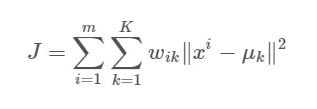

Where:
   - *k* represents the number of clusters (groups)
   - *m* represents the number of points
   - *u_k* represents centroids
   - *x_i* represents data point
   - *w_ik* represents weight where wik=1 for data point xi if it belongs to cluster k; otherwise, wik=0.

There are some typical applications of using k-means:
- Customer Segmentation: k-means can segment customers based on their demographic information or purchase behavior. This information can then be used for targeted marketing or to improve the customer experience.

- Image Compression: k-means can reduce the number of colors in an image while preserving its visual quality. This is done by replacing similar color pixels with a single color, thereby reducing the amount of data required to represent the image.

- Anomaly Detection: k-means can be used to identify outliers or anomalies in a dataset by clustering similar data points and identifying data points far from the centroids of their respective clusters.

- Document Clustering: k-means can cluster documents based on their content, for example, to group news articles by topic or categorize customer support tickets.

- Market Segmentation: k-means can be used to segment a market based on customer characteristics, such as age, income, or spending habits, in order to identify subgroups of customers with similar needs or preferences.


Recomended sources:
 - https://towardsdatascience.com/log-book-guide-to-distance-measuring-approaches-for-k-means-clustering-f137807e8e21
 - https://towardsdatascience.com/understanding-k-means-clustering-in-machine-learning-6a6e67336aa1
 - https://realpython.com/k-means-clustering-python/
 - https://medium.com/@rishit.dagli/build-k-means-from-scratch-in-python-e46bf68aa875
 - https://towardsdatascience.com/k-means-clustering-algorithm-applications-evaluation-methods-and-drawbacks-aa03e644b48a
 - https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

# Exercise 1 - K-means from scratch

## Implementing K-means

In this exercise, the task would be to implement a simple k-means algorithm from scratch, as described above. Let's rewrite the steps to be more readily implementable

### Steps:
  1. Specify the number of clusters *K*
  2. initialize centroids
  3. calculate the distance from centroids to all points in datasets
  4. assign data points to the closest centroids
  5. calculate objective function
  6. compute new centroids to the clusters by taking the average of all data points that belong to each cluster
  7. repeat steps 2-6. until there is no change in objective function or until the maximum n of iterations is reached


Tips:
- Avoid using loops; if it is unnecessary, instead of using loops, use NumPy functions. There is a list of NumPy functions that you might find helpful:
    - np.argmin()
    - np.where()
    - np.transpose()
    - np.random.permutation()
    - np.random.schuffle()
    - np.linalg.norm()
    - np.arange()
    - np.split()
    - np.random.choice()



- Since the initial clusters are selected randomly, the algorithm can lead to different results each time it runs. Running the algorithm multiple times and determining the result with the lowest objective function helps obtain the best results.


### Code

**Please note that the code structure provided below is only a recommendation. If you prefer, you can use your code structure. If you are familiar with OOP, you can also use it. However, writing your code in one function or not using functions at all is not the recommended approach**

In [ ]:
import matplotlib.pyplot as plt
import copy
import numpy as np
from numpy.linalg import norm
from sklearn.cluster import KMeans

### 0. Load dataset

Use the following code to load data

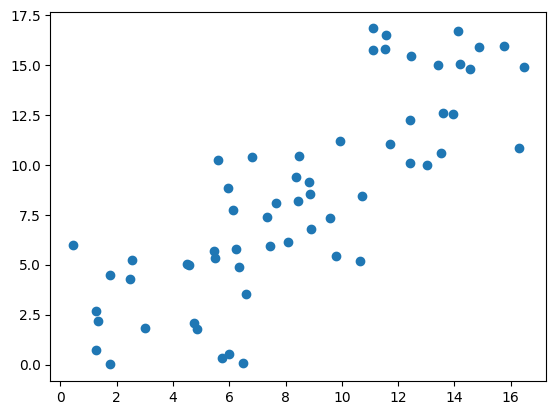

In [ ]:
loaded_points = np.load('Data/k_mean_points.npy')
plt.figure()
plt.scatter(loaded_points[:,0],loaded_points[:,1])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1. Specify number of clusters *K*

In [ ]:
k = 3

### 2. initialize centroids

There are more techniques, on how to change initial centroids. In out case, we will take all available points and shuffle them randomly, then we will choose first *k_clusters* points as initial centroids

In [ ]:
def initialize_clusters(points: np.ndarray, k_clusters: int) -> np.ndarray:

    ###################################
    # Write your own code here #
    n_points = points.shape[0]
    random_indices = np.random.choice(n_points, k_clusters, replace=False)
    initial_clusters = points[random_indices]
    ###################################

    return initial_clusters



[[13.40534787 15.00845647]
 [ 8.87457308  8.53148228]
 [10.72529411  8.44486038]]


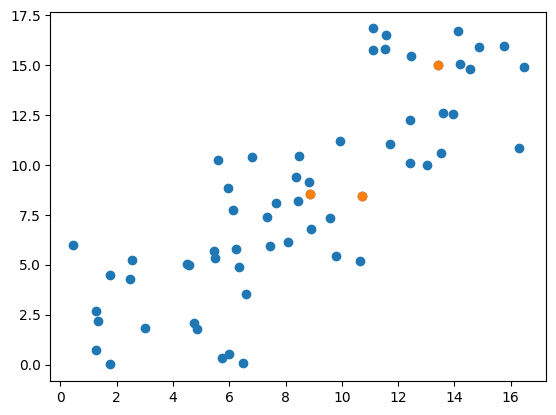

In [ ]:
ini_clusters = initialize_clusters(loaded_points,k)
print(ini_clusters)
plt.figure()
plt.scatter(loaded_points[:,0],loaded_points[:,1])
plt.scatter(ini_clusters[:,0],ini_clusters[:,1])

### 3. Calculate distance from centroids to all points in datasets

3.1 Fistly, create a function to calculate distance from one centroid to all points in the dataset

In [ ]:
def calculate_metric(points: np.ndarray, centroid: np.ndarray) -> np.ndarray:
    ###################################
    # Write your own code here #

    distances_array = np.linalg.norm((points-centroid), axis=1)


    ###################################

    return distances_array

In [ ]:
cal_metric = calculate_metric(loaded_points,ini_clusters[1])
print(cal_metric)

[ 7.85154771  5.47882027  4.43440067  4.6556256   4.43521021  8.79610001
  7.64237499  5.59977617  7.1275753  10.89707144 11.09462878  8.76538962
  8.88412875  8.75321063  9.5801497   9.84817185  7.67582766  8.1730525
  8.47359848  5.58128158  0.9897508   1.91194983  2.78496495  3.69617926
  1.36656341  0.64170054  2.83923519  1.85274706  1.28678965  0.55828806
  3.77430394  2.87586958  3.22884197  3.79833955  2.98007462  1.75848382
  2.94842739  1.97918738  0.          2.50603744  8.43814887  9.91720058
  7.79493421  7.90437315  6.21965995  9.73387797  6.46828774  5.15000862
  5.07385822  3.87349937  4.42497448  8.41530147  8.45938798  7.55215496
  7.7804905   7.7801274   9.51122872 10.14284985  8.6092046   3.79304038]


3.2 Secondly, create a function to calculate distance between points and all centroids using function from 3.1

In [ ]:
def compute_distances(points: np.ndarray, centroids_points: np.ndarray) -> np.ndarray:

    ###################################
    # Write your own code here #

    distances_array = np.asarray([calculate_metric(points,centroid) for centroid in centroids_points])
    ###################################

    return distances_array

In [ ]:
distances = compute_distances(loaded_points,ini_clusters)
print(distances.shape)
print(distances)

(3, 60)
[[15.74560155 13.33183725 12.23725998 12.49838969 12.33957081 15.78229786
  15.54383688 13.37082942 14.59461164 18.74185968 18.98255688 16.54644386
  16.76279061 16.4241719  17.2828755  17.60397718 15.30249551 15.68295657
  16.2346759  13.36251813  7.53642018  9.74269531  8.04386578  9.1279068
   8.54481235  7.4157618  10.26985025  7.08967431  8.9857745   8.43625285
  10.19888342  5.14869532 10.23530343 11.67041698 10.87198269  9.38303501
   9.66458511  6.70049734  7.90437315 10.32981382  2.37786579  3.06383609
   1.06584177  0.          2.42887655  1.86288754  2.51181095  2.9218655
   4.41271329  4.99973676  5.00064982  0.80393816  1.18194728  2.4180719
   5.0608288   2.04294792  1.72424404  2.54593758  2.93740681  4.30932581]
 [ 7.85154771  5.47882027  4.43440067  4.6556256   4.43521021  8.79610001
   7.64237499  5.59977617  7.1275753  10.89707144 11.09462878  8.76538962
   8.88412875  8.75321063  9.5801497   9.84817185  7.67582766  8.1730525
   8.47359848  5.58128158  0.9897

### 4. Assign datapoints to the closest centroids

In [ ]:
def assign_centroids(distances: np.ndarray) -> np.ndarray:

    ###################################
    # Write your own code here #

    assigned_centroids = np.argmin(distances, axis = 0)
    ###################################

    return assigned_centroids

In [ ]:
assigned_centroid = assign_centroids(distances)
print(assigned_centroid)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 2 2 2 1 1 1 1
 1 1 1 0 0 0 0 0 0 0 0 2 2 2 0 0 0 0 0 0 0 0 2]


### 5. Calculate objective function

In [ ]:
def calculate_objective(assigned_centroids: np.ndarray, distances: np.ndarray) -> np.float32:
    indices = assigned_centroids.astype(int).flatten()
    n_points = distances.shape[1]
    point_indices = np.arange(n_points)
    relevant_distances = distances[indices, point_indices]
    objective_function_value = np.sum(relevant_distances ** 2)

    ###################################

    return np.float32(objective_function_value)

In [ ]:
value = calculate_objective(assigned_centroid,distances)
print(value)

1504.4138


### 6. Compute new controids to the clusters by taking the average of the all data points that belong to each cluster

In [ ]:
def calculate_new_centroids(points: np.ndarray, assigned_centroids: np.ndarray, k_clusters: int) -> np.ndarray:

    labels = assigned_centroids.flatten()
    new_clusters_list = []
    for i in range(k_clusters):

        current_cluster_points = points[labels == i]
        if len(current_cluster_points) > 0:
            mean_position = current_cluster_points.mean(axis=0)
        else:
            mean_position = np.zeros(points.shape[1])

        new_clusters_list.append(mean_position)
    new_clusters = np.array(new_clusters_list, dtype=np.float32)

    ###################################

    return new_clusters

[[13.590435  14.814853 ]
 [ 5.5395684  5.346505 ]
 [11.470242   9.005845 ]
 [ 0.         0.       ]
 [ 0.         0.       ]]


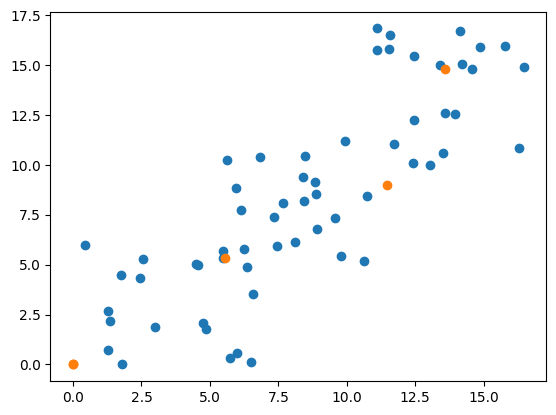

In [ ]:
new_points = calculate_new_centroids(loaded_points,assigned_centroid,5)
print(new_points)
plt.figure()
plt.scatter(loaded_points[:,0],loaded_points[:,1])
plt.scatter(new_points[:,0],new_points[:,1])

###   7. repeat steps 2-6. until there is no change in objective function or until the maximum n of iterations is reached

In [ ]:
def fit(points: np.ndarray, k_clusters: int, n_of_iterations: int, error: float = 0.001) -> tuple:
    ###################################

    centroid_points = initialize_clusters(points, k_clusters)
    last_objective = 10000.0

    for _ in range(n_of_iterations):
        distances = compute_distances(points, centroid_points)
        assigned_centroids = assign_centroids(distances)

        current_objective = calculate_objective(assigned_centroids, distances)

        if abs(last_objective - current_objective) < error:
            break

        last_objective = current_objective

        new_points = calculate_new_centroids(points, assigned_centroids, k_clusters)

        centroid_points = new_points

    ###################################

    return centroid_points, last_objective

Final Objective Value: 436.2519836425781


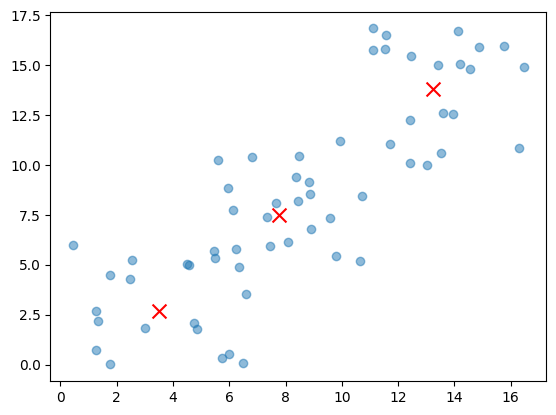

In [ ]:
n_of_iterations = 50
n_of_clusters = 3
error = 0.005

# Make sure to catch both return values
centroids, value = fit(loaded_points, n_of_clusters, n_of_iterations, error)

print(f"Final Objective Value: {value}")

plt.figure()
plt.scatter(loaded_points[:,0], loaded_points[:,1], alpha=0.5)
plt.scatter(centroids[:,0], centroids[:,1], c='red', s=100, marker='x')
plt.show()

# Evaluation methods - How to determine *k*?

One of the disadvantages of using k-means is that it requires a number of centroids *k* as an input, and it is not usually that obvious. Some methods exist to choose the correct number of centroids at the beginning. In this part of the lecture, we will describe two methods to select the right *k* value: *Elbow method* and *Silhouette analysis*

## Elbow method

The Elbow Method is a technique used in determining the optimal number of clusters for k-means clustering. The basic idea is to plot the explained variation as a function of the number of clusters and pick the elbow of the curve as the number of clusters to use. In the picture below you can see that the best *k* value is 3

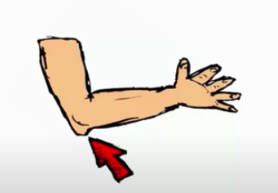 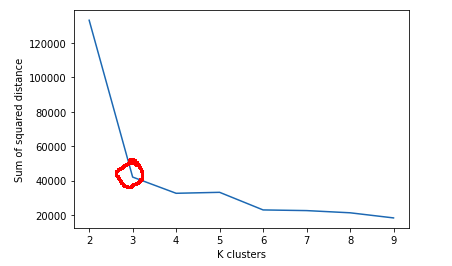

The main advantage of this method that its very simple and easy to implement, on the other hand sometimes it is not very clear where the elbow is

## Silhouette analysis

Silhouette analysis is a method to evaluate the quality of clustering results by measuring how similar each data point is to its own cluster compared to other clusters. A high silhouette score indicates that the data points in a cluster are well-separated from other clusters and that the clustering solution is good.

The silhouette score can be calculated using the following formula. This measure has a range of [-1, 1] and it is calculated for each sample in the dataset

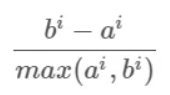

where:
 - a_i represents the average distance of that point with all other points in the same clusters
 - b_i represents the average distance of that point with all the points in the closest cluster to its cluster

if
 - is 0 –> the sample is very close to the neighboring clusters.
 - is 1 –> the sample is far away from the neighboring clusters.
 - is -1 –> the sample is assigned to the wrong clusters.

## Exercise 2 - Implementing an Elbow Method

Implementing an elbow method is simple,
 1. Create a vector of possible *k* values
 2. Fit your data using different *k* values and save the objective function value
 3. Plot objective function values in terms of *k* values
 4. Find an elbow

In [ ]:
k_all = range(2, 10)
all_objective = []

for k in k_all:
    _, obj_val = fit(loaded_points, k, 100, 0.001)
    all_objective.append(obj_val)



Text(0, 0.5, 'Sum of squared distance')

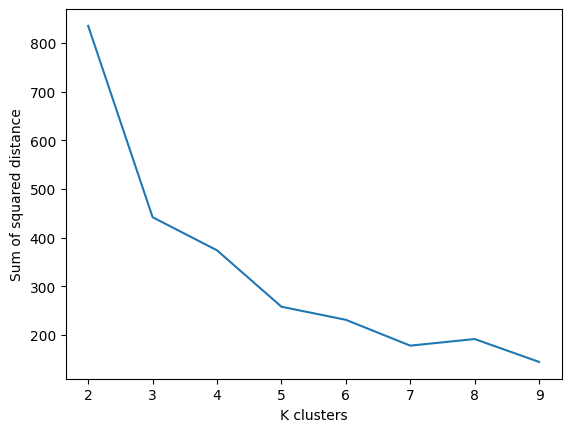

In [ ]:
plt.figure()
plt.plot(k_all, all_objective)
plt.xlabel('K clusters')
plt.ylabel('Sum of squared distance')

# Exercise 3 - Image Compression

In this exercise, the task would be to implement simple image compression using the k-means algorithm. You can use an image in the directory *Data\\*. This time, we will use a library that implements k-means for us - *sklearn* https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html. To load the image you can use *openCv* or *matplotlib* (or anything else)

### Steps

   1. Firstly reshape your image to 2D array with shape (image.width*image.height, n_of_colour_channels)
   2. Initialize the K_means algorithm, where K would be equal to the number of colours in the compressed image
   3. check cluster centroids and convert them to integers - these are your new colours (kmeans.cluster_centers_ could be useful)
   4. replace your 2D array colors with newly generated colors
   5. reshape your 2D array to the original image shape

Tips:
- it takes a couple of seconds to compress the attached image. For debugging purposes, you can use a custom smaller image
- the implementation can be done in a single function

In [ ]:
from matplotlib.image import imread
from sklearn.cluster import KMeans
import numpy as np

### 1. load image

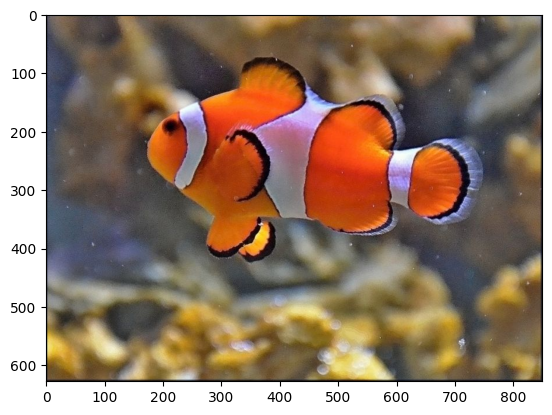

In [ ]:
loaded_image = imread('Data/fish.jpg')

plt.imshow(loaded_image)
plt.show()

In [122]:
def compress_image(image: np.ndarray, number_of_colours: int) -> np.ndarray:
    """
    Compresses the given image by reducing the number of colours used in the image.
    """


    if image.max() > 1:
        image_data = image / 255.0
    else:
        image_data = image

    h, w, c = image_data.shape

    pixels = image_data.reshape(-1, c)

    kmeans = KMeans(n_clusters=number_of_colours, random_state=42, n_init=10)
    kmeans.fit(pixels)

    compressed_pixels = kmeans.cluster_centers_[kmeans.labels_]

    compressed_image = compressed_pixels.reshape(h, w, c)

    return compressed_image


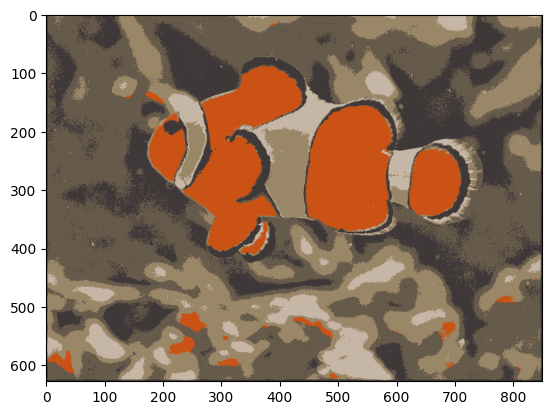

In [124]:
img = compress_image(loaded_image, 5)

plt.figure()
plt.imshow(img)
plt.show()